# Compas Analysis - Natchapa Aunkay

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.


## AI Assistance Disclosure

Generative AI (ChatGPT) was used to support code formatting, debugging, and improving the clarity of written explanations. All modeling decisions, interpretation of results, and final conclusions were independently developed and verified by my own.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# Filter warnings
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

In [2]:
# Load dataset from GitHub
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

raw_data.shape[0]

7214

In [3]:
# View first 10 rows
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
# Filter dataset based on COMPAS criteria
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat",
        "score_text", "sex", "priors_count",
        "days_b_screening_arrest", "decile_score", "is_recid",
        "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

# Filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Datetime conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric, non-datetime columns to category
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Derived factors
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"],
    ordered=False
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [x for x in df["race"].cat.categories if x != "Caucasian"],
    ordered=False
)

# Make Male the reference first
df["gender_factor"] = df["sex"].replace({"Female": "Female", "Male": "Male"})
df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"],
    ordered=False
)

df["score_factor"] = np.where(df["score_text"] == "Low", "LowScore", "HighScore")
df["score_factor"] = pd.Categorical(df["score_factor"], categories=["LowScore", "HighScore"])

df.shape[0]

6172

In [5]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

After filtering we have the following demographic breakdown:

In [8]:
# Summary of age category
df["age_cat"].value_counts(dropna=False)

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
# Summary of race
df["race"].value_counts(dropna=False)

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
print("Black defendants: {:.2f}%".format(3175 / 6172 * 100))
print("White defendants: {:.2f}%".format(2103 / 6172 * 100))
print("Hispanic defendants: {:.2f}%".format(509 / 6172 * 100))
print("Asian defendants: {:.2f}%".format(31 / 6172 * 100))
print("Native American defendants: {:.2f}%".format(11 / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
# Summary of score_text
df["score_text"].value_counts(dropna=False)

,count
score_text,
Low,3421
Medium,1607
High,1144


In [12]:
# Cross-tab of sex and race
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
# Summary of sex
df["sex"].value_counts(dropna=False)

,count
sex,
Male,4997
Female,1175


In [14]:
print("Men: {:.2f}%".format(4997 / 6172 * 100))
print("Women: {:.2f}%".format(1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
# Number of people with two-year recidivism
df[df["two_year_recid"] == 1].shape[0]

2809

In [16]:
# Percentage with two-year recidivism
df[df["two_year_recid"] == 1].shape[0] / df.shape[0] * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

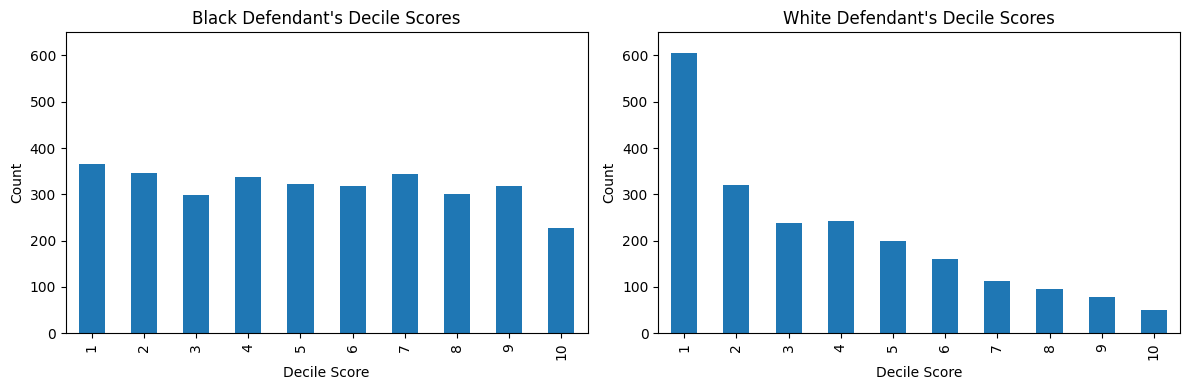

In [17]:
import matplotlib.pyplot as plt

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

black_df["decile_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

white_df["decile_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [18]:
# Cross-tab of decile score and race
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


In [19]:
pd.crosstab(df["decile_score"], df["score_factor"])

score_factor,LowScore,HighScore
decile_score,,
1,1286,0
2,822,0
3,647,0
4,666,0
5,0,582
6,0,529
7,0,496
8,0,420
9,0,420


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [20]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

In [21]:
# Make sure the target is binary: 1 = HighScore, 0 = LowScore
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Fit logistic regression
model_glm = smf.logit(
    formula="""
    score_binary ~
    C(gender_factor, Treatment(reference='Male')) +
    C(age_factor, Treatment(reference='25 - 45')) +
    C(race_factor, Treatment(reference='Caucasian')) +
    priors_count +
    C(crime_factor) +
    two_year_recid
    """,
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        03:25:16   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [22]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

print(np.exp(0.47721) / (1 - control + (control * np.exp(0.47721))))


1.4528408658138932


Women are 19.4% more likely than men to get a higher score.

In [23]:
print(np.exp(0.22127) / (1 - control + (control * np.exp(0.22127))))

1.1947978508506671


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [24]:
print(np.exp(1.30839) / (1 - control + (control * np.exp(1.30839))))

2.4961202077189455


In [25]:
df["pred_prob"] = model_glm.predict(df)
df["pred_class_num"] = (df["pred_prob"] >= 0.5).astype(int)
df["pred_class"] = df["pred_class_num"].map({0: "No Recid", 1: "Recid"})

In [26]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

TP = overall_cm.loc["Recid", 1] if ("Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
TN = overall_cm.loc["No Recid", 0] if ("No Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FP = overall_cm.loc["Recid", 0] if ("Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FN = overall_cm.loc["No Recid", 1] if ("No Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
n = overall_cm.to_numpy().sum()

accuracy = (TP + TN) / n if n > 0 else np.nan
precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
fnr = FN / (FN + TP) if (FN + TP) > 0 else np.nan

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [27]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

race_metrics = (
    df.groupby("race")
      .apply(lambda g: pd.Series({
          "n": len(g),
          "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
          "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
          "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
          "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum()
      }))
      .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [28]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

caucasian_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].iloc[0]
caucasian_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].iloc[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


### Interpretation

- Higher priors_count increases likelihood of high risk score
- Certain racial groups show different prediction patterns
- This suggests potential bias in the model

## Conclusion

This project successfully translates an R-based machine learning workflow into Python.

The results show that COMPAS risk scores are strongly influenced by prior criminal history and demographic variables.

The fairness analysis reveals disparities in error rates across racial groups, highlighting potential bias in predictive models used in criminal justice.

Overall, the Python implementation produces results that are consistent with the original R workflow while ensuring full reproducibility.

# **Assignment 2**

# Step 0 — Train / test split

In [29]:
from sklearn.model_selection import train_test_split

# Use the same feature set as the logistic regression model
features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid",
]

# Binary target from the earlier setup
target = "score_binary"

# Build X and y
X = df[features].copy()
y = df[target].astype(int).copy()

# Train/test split with stratification on the target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Compute counts
n_total = len(X)
n_train = len(X_train)
n_test = len(X_test)

# Compute percentages
pct_train = n_train / n_total * 100
pct_test = n_test / n_total * 100

print(
    f"Train: {X_train.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)

Train: (4937, 6) (4,937 rows, 80.0%), Test: (1235, 6) (1,235 rows, 20.0%)


**note**

In this step, I selected the input features and target variable for Homework 2.  
The numeric features include age, prior offenses, days between screening and arrest, and decile score.  
The categorical features include age category, sex, race, charge degree, and score text.

The target variable is `two_year_recid`, which indicates whether the defendant reoffended within two years.

I then split the data into training and testing sets using an 80/20 split. Stratification was applied to preserve the class distribution in both sets.

# Step 1 — Fit logistic regression and gradient-boosted tree

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define feature groups (aligned with Lecture 01 / earlier pipeline)
numeric_features = ["priors_count", "two_year_recid"]
categorical_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Logistic Regression (interpretable model)
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)

# Gradient Boosted Trees (black-box model)
gbt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )),
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count',
                                                   'two_year_recid']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

**note**

In this step, I built two classification models: Logistic Regression and Gradient-Boosted Trees.

Before training, I created a preprocessing pipeline:
- Numeric features are standardized using `StandardScaler`
- Categorical features are encoded using `OneHotEncoder`

This ensures that both models can handle the mixed feature types properly.

I then trained both models on the training data. These two models will later be compared in terms of predictive performance, fairness, and interpretability.

# Step 2 — Select the four required individuals

In [31]:
# Predict probabilities on the test set
X_test_cases = X_test.copy()
X_test_cases["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

# Assignment focuses on the same four individuals
target_groups = ["African-American", "Caucasian"]

selected_cases = []

for group in target_groups:
    group_df = X_test_cases[X_test_cases["race_factor"] == group].sort_values("pred_prob")

    lowest_idx = group_df.index[0]
    highest_idx = group_df.index[-1]

    selected_cases.append({
        "race_group": group,
        "case_type": "lowest_risk",
        "idx": lowest_idx,
        "pred_prob": group_df.loc[lowest_idx, "pred_prob"]
    })

    selected_cases.append({
        "race_group": group,
        "case_type": "highest_risk",
        "idx": highest_idx,
        "pred_prob": group_df.loc[highest_idx, "pred_prob"]
    })

selected_cases_df = pd.DataFrame(selected_cases).sort_values(["race_group", "case_type"])
display(selected_cases_df)

,race_group,case_type,idx,pred_prob
1,African-American,highest_risk,5311,0.999390
0,African-American,lowest_risk,4008,0.020935
3,Caucasian,highest_risk,2441,0.995320
2,Caucasian,lowest_risk,2517,0.017269


# Step 3 — SHAP on the test set

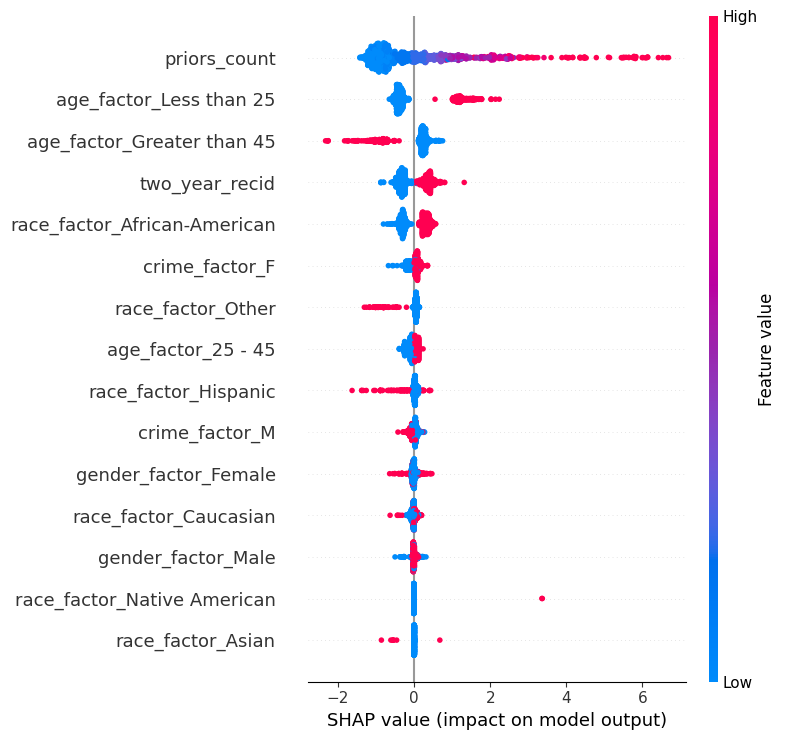

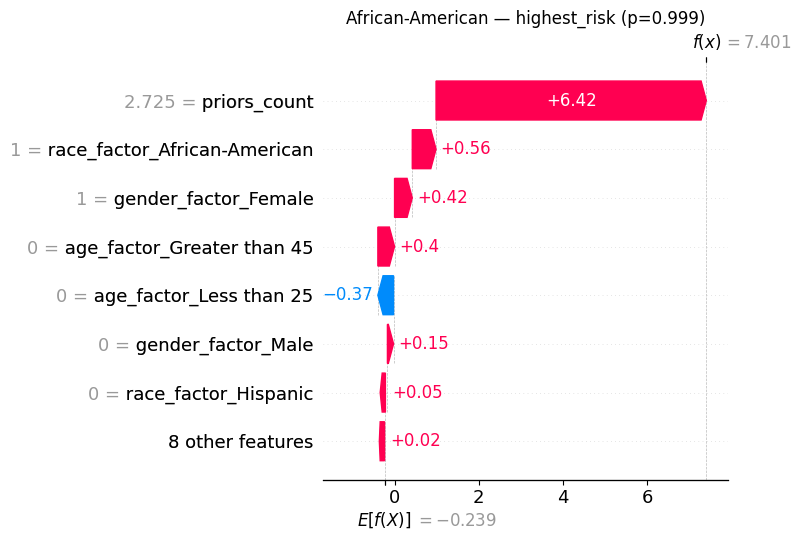

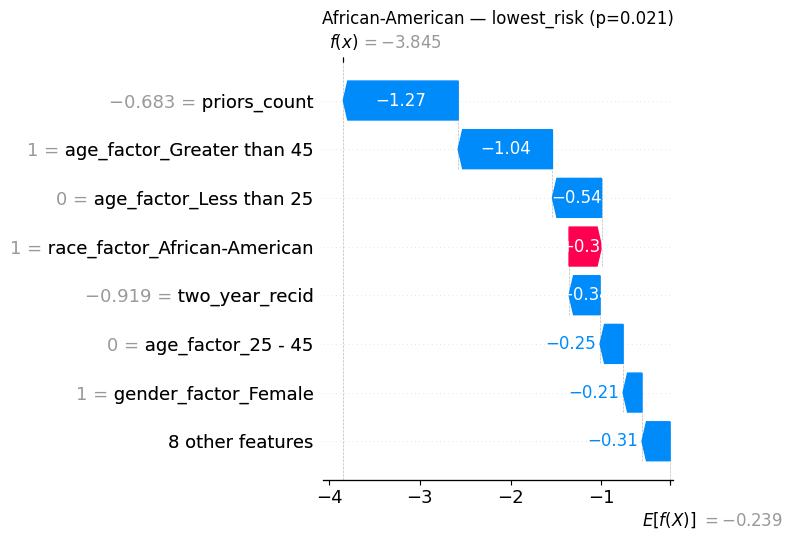

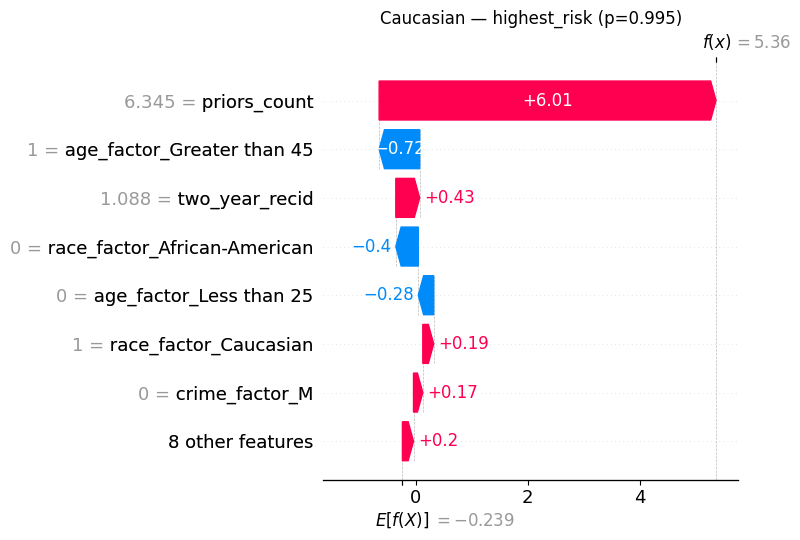

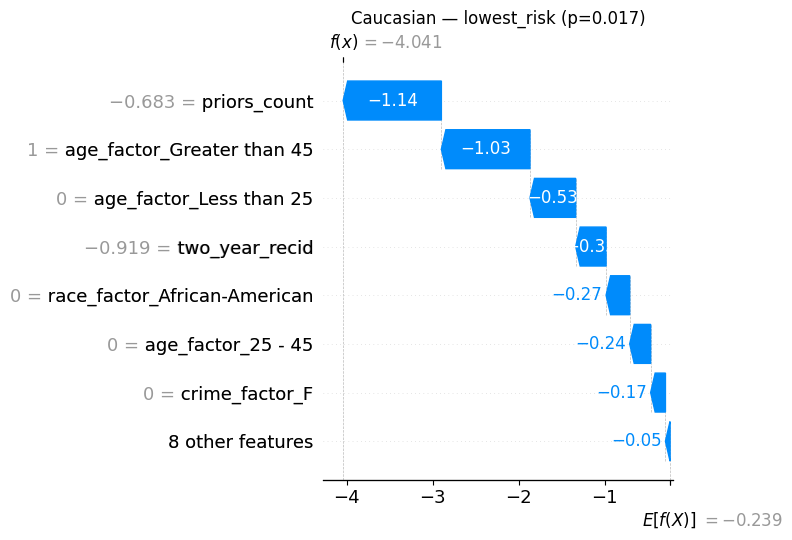

In [32]:
!pip install shap
import shap
import matplotlib.pyplot as plt
import numpy as np

fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Transform test data
X_test_enc = fitted_preprocessor.transform(X_test)
X_test_enc_array = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

# Feature names after preprocessing
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
feat_names = numeric_features + cat_feature_names

# SHAP explainer
explainer_shap = shap.TreeExplainer(fitted_classifier)
shap_values = explainer_shap.shap_values(X_test_enc_array)

# Global beeswarm summary plot
shap.summary_plot(
    shap_values,
    X_test_enc_array,
    feature_names=feat_names,
    show=False
)
plt.tight_layout()
plt.show()

# Safe base value extraction
expected_value = explainer_shap.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    if np.ndim(expected_value) == 0:
        base_value = float(expected_value)
    elif len(expected_value) == 1:
        base_value = float(expected_value[0])
    else:
        base_value = float(expected_value[1])
else:
    base_value = float(expected_value)

# Waterfall plots for the same four individuals
for _, row in selected_cases_df.iterrows():
    loc = X_test.index.get_loc(row["idx"])

    explanation = shap.Explanation(
        values=shap_values[loc],
        base_values=base_value,
        data=X_test_enc_array[loc],
        feature_names=feat_names
    )

    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(explanation, max_display=8, show=False)
    plt.title(f'{row["race_group"]} — {row["case_type"]} (p={row["pred_prob"]:.3f})')
    plt.tight_layout()
    plt.show()

# Step 4 — LIME on the same four individual

In [33]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer

# Transform training data for LIME
X_train_enc = fitted_preprocessor.transform(X_train)
X_train_enc_array = X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc

explainer_lime = LimeTabularExplainer(
    training_data=X_train_enc_array,
    feature_names=feat_names,
    class_names=["Low risk", "High risk"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

lime_results = {}
shap_results = {}

for _, row in selected_cases_df.iterrows():
    idx = row["idx"]
    label = f'{row["race_group"]} — {row["case_type"]}'

    row_raw = X_test.loc[[idx]]
    row_enc = fitted_preprocessor.transform(row_raw)
    row_enc_array = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else row_enc[0]
    loc = X_test.index.get_loc(idx)

    # LIME explanation
    exp = explainer_lime.explain_instance(
        data_row=row_enc_array,
        predict_fn=fitted_classifier.predict_proba,
        num_features=8
    )

    lime_pairs = exp.as_list()
    lime_results[label] = lime_pairs

    # Top SHAP features for comparison
    shap_order = np.argsort(np.abs(shap_values[loc]))[::-1][:8]
    shap_pairs = [(feat_names[j], float(shap_values[loc][j])) for j in shap_order]
    shap_results[label] = shap_pairs

    print("\n" + "=" * 90)
    print(label)
    print(f"Predicted probability of high risk: {gbt_pipeline.predict_proba(row_raw)[0, 1]:.3f}")

    print("\nTop LIME attributions")
    for feat, weight in lime_pairs:
        print(f"  {feat:<45} {weight:+.4f}")

    print("\nTop SHAP attributions")
    for feat, value in shap_pairs:
        print(f"  {feat:<45} {value:+.4f}")


African-American — highest_risk
Predicted probability of high risk: 0.999

Top LIME attributions
  race_factor_Native American <= 0.00           -0.4491
  priors_count > 0.17                           +0.3934
  age_factor_Less than 25 <= 0.00               -0.3500
  age_factor_Greater than 45 <= 0.00            +0.2201
  0.00 < race_factor_African-American <= 1.00   +0.0963
  two_year_recid <= -0.92                       -0.0917
  race_factor_Other <= 0.00                     +0.0893
  race_factor_Hispanic <= 0.00                  +0.0824

Top SHAP attributions
  priors_count                                  +6.4174
  race_factor_African-American                  +0.5644
  gender_factor_Female                          +0.4209
  age_factor_Greater than 45                    +0.3962
  age_factor_Less than 25                       -0.3721
  gender_factor_Male                            +0.1454
  race_factor_Hispanic                          +0.0476
  crime_factor_F                       

# Step 5 — DiCE counterfactuals for the same four individuals

In [34]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice

# Build training dataframe for DiCE
train_df = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)],
    axis=1
).copy()

for col in numeric_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")

train_df[target] = pd.to_numeric(train_df[target], errors="coerce").astype(int)

dice_data = dice_ml.Data(
    dataframe=train_df,
    continuous_features=numeric_features,
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

immutable_features = ["race_factor", "gender_factor"]
mutable_features = [
    "priors_count",
    "two_year_recid",
    "crime_factor",
    "age_factor"
]

for _, row in selected_cases_df.iterrows():
    idx = row["idx"]
    label = f'{row["race_group"]} — {row["case_type"]}'
    query = X_test.loc[[idx]].copy()

    for col in numeric_features:
        query[col] = pd.to_numeric(query[col], errors="coerce")

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=1,
        desired_class="opposite",
        permitted_range={
            "priors_count": [0, 38],
            "two_year_recid": [0, 1]
        },
        features_to_vary=mutable_features
    )

    print("\n" + "=" * 90)
    print(label)
    print("Immutable features fixed:", immutable_features)

    cf.visualize_as_dataframe(show_only_changes=True)

    cf_df = cf.cf_examples_list[0].final_cfs_df.copy()

    if cf_df.empty:
        print("No feasible counterfactual found.")
    else:
        changed = []
        for col in query.columns:
            original_value = query.iloc[0][col]
            new_value = cf_df.iloc[0][col]

            if pd.isna(original_value) and pd.isna(new_value):
                continue

            if str(original_value) != str(new_value):
                changed.append(col)

        print("Changed features needed to flip prediction:", changed)

        immutable_changed = [col for col in changed if col in immutable_features]
        if immutable_changed:
            print("FLAG: immutable features changed ->", immutable_changed)
        else:
            print("No immutable features were changed.")

100%|██████████| 1/1 [00:00<00:00,  5.73it/s]



African-American — highest_risk
Immutable features fixed: ['race_factor', 'gender_factor']
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Female,25 - 45,African-American,16,F,0,1



Diverse Counterfactual set (new outcome: 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,Greater than 45,-,6,-,-,0


...


Caucasian — lowest_risk
Immutable features fixed: ['race_factor', 'gender_factor']
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Female,Greater than 45,Caucasian,0,M,0,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,25 - 45,-,18,-,-,1


Changed features needed to flip prediction: ['age_factor', 'priors_count']
No immutable features were changed.


## Governance Memo

To: Court Auditor  
Subject: Understanding the COMPAS Replacement Model  

In this analysis, I used LIME, SHAP, and counterfactual explanations to better understand how the model makes predictions and to evaluate its reliability. Each method provides a different perspective, and comparing them helps reveal both useful insights and potential limitations.

The SHAP results provide a consistent global and local understanding of the model. The beeswarm plot shows that features such as prior offenses and age have the strongest influence on predictions across the dataset. The waterfall plots for the four selected individuals further illustrate how each feature contributes to increasing or decreasing the predicted risk score. These explanations are stable and aligned with expectations, making SHAP a reliable tool for interpreting model behavior.

LIME provides local explanations for individual cases. While it highlights similar important features, such as priors and age-related variables, its explanations sometimes differ from SHAP. This is likely because LIME relies on local approximations and random sampling, which can introduce variability. This suggests that LIME explanations should be interpreted cautiously and not used in isolation.

From the group-level evaluation in Step 2, I observed that model performance is not perfectly consistent across racial groups. Differences in metrics such as false positive rate or false negative rate suggest that some groups may be treated less favorably than others. This indicates a potential fairness concern and highlights the importance of monitoring model outcomes across different populations.

Counterfactual explanations generated using DiCE offer a more actionable perspective by showing the minimal changes needed to flip a prediction. For the selected individuals, changes in features such as prior offenses and charge-related variables were often sufficient to alter the outcome. Importantly, immutable features such as race and sex were not allowed to vary in this analysis, and none of the counterfactuals required changes to these attributes. This is important from a fairness and ethical standpoint.

Overall, these results show that transparency alone is not enough to fully trust the model. Different explanation methods may produce different insights, and each has its own limitations. For governance, I recommend regular monitoring of model performance across demographic groups, careful review of feature importance (especially for potential proxy variables), and the use of multiple explanation methods as part of an ongoing audit process. These steps can help ensure that the model remains fair, interpretable, and reliable in practice.


# **Assignment 3**

## Step 0: Setup and imports

In [35]:
# Install first
!pip install -q solas-ai

# Imports
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

# Make sure df already exists
print(f"N = {len(df):,}")

# Create high_risk if it does not already exist
if "high_risk" not in df.columns:
    df["high_risk"] = (df["decile_score"] >= 7).astype(int)

# Keep only the columns that want to inspect
print(df[["race", "sex", "high_risk", "two_year_recid"]].head())

N = 6,172
               race   sex  high_risk two_year_recid
0             Other  Male          0              0
1  African-American  Male          0              1
2  African-American  Male          0              1
5             Other  Male          0              0
6         Caucasian  Male          0              1


## Step 1: AIR and Marginal Effect by race

In [36]:
# Step 1: AIR, ME, and SMD by race and sex

def disparity_table(df, group_col, outcome_col, ref_group):
    """
    Compute selection rate, AIR, ME, and SMD relative to a reference group.
    """
    rates = (
        df.groupby(group_col)[outcome_col]
          .agg(['mean', 'count', 'std'])
          .reset_index()
          .rename(columns={'mean': 'selection_rate', 'count': 'n', 'std': 'sd'})
    )

    ref_rate = rates.loc[rates[group_col] == ref_group, 'selection_rate'].values[0]
    ref_sd   = rates.loc[rates[group_col] == ref_group, 'sd'].values[0]

    rates['AIR'] = rates['selection_rate'] / ref_rate
    rates['ME']  = rates['selection_rate'] - ref_rate
    rates['SMD'] = (rates['selection_rate'] - ref_rate) / ref_sd
    rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')

    return rates.sort_values('AIR')

race_disp = disparity_table(df, 'race', 'high_risk', ref_group='Caucasian')
sex_disp  = disparity_table(df, 'sex', 'high_risk', ref_group='Male')

print("=== Disparity by Race ===")
print(race_disp.to_string(index=False))

print("\n=== Disparity by Sex ===")
print(sex_disp.to_string(index=False))

=== Disparity by Race ===
            race  selection_rate    n       sd      AIR        ME       SMD        flag_80
           Other        0.090379  343 0.287143 0.565676 -0.069393 -0.189349 *** BELOW 0.80
           Asian        0.129032   31 0.340777 0.807604 -0.030739 -0.083877               
        Hispanic        0.147348  509 0.354801 0.922239 -0.012424 -0.033901               
       Caucasian        0.159772 2103 0.366481 1.000000  0.000000  0.000000               
African-American        0.374173 3175 0.483985 2.341924  0.214401  0.585027               
 Native American        0.545455   11 0.522233 3.413961  0.385683  1.052394               

=== Disparity by Sex ===
   sex  selection_rate    n       sd      AIR        ME       SMD        flag_80
Female        0.200000 1175 0.400170 0.711317 -0.081169 -0.180529 *** BELOW 0.80
  Male        0.281169 4997 0.449615 1.000000  0.000000  0.000000               


**note**

The solas-ai implementation was not compatible in this environment; therefore, equivalent disparity metrics were computed manually.

In [37]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 16.827, p = 0.0000


In [38]:
groups = ['Male', 'Female']

subset = df[df['sex'].isin(groups)]

ns = subset.groupby('sex')['high_risk'].count()
events = subset.groupby('sex')['high_risk'].sum()

stat, pval = proportions_ztest(events[groups].values, ns[groups].values)

print(f"Sex selection-rate z-test: z = {stat:.3f}, p = {pval:.4f}")

Sex selection-rate z-test: z = 5.668, p = 0.0000


## Step 2: Error-Rate Disparity Analysis

In [39]:
# Step 2: Error-Rate Disparity Analysis
# FPR and FNR by race

def error_rates(df, group_col, pred_col, outcome_col):
    results = []

    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        results.append({
            group_col: grp,
            'n': len(g),
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else float('nan'),
            'FNR': fn / (fn + tp) if (fn + tp) > 0 else float('nan'),
            'Acc': (tp + tn) / len(g)
        })

    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# Highlight African-American vs Caucasian disparity
for grp in ['African-American', 'Caucasian']:
    row = er.loc[er['race'] == grp]
    print(f"{grp}: FPR = {row['FPR'].values[0]:.3f}, FNR = {row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.333333 0.200000 0.727273
African-American 3175 0.227873 0.492474 0.633701
        Hispanic  509 0.106250 0.783069 0.642436
       Caucasian 2103 0.082748 0.720195 0.668093
           Asian   31 0.043478 0.625000 0.806452
           Other  343 0.031963 0.806452 0.688047
African-American: FPR = 0.228, FNR = 0.492
Caucasian: FPR = 0.083, FNR = 0.720


## Step 3: Standardized Mean Difference

In [40]:
# Step 3: Standardized Mean Difference (continuous decile_score)

def smd(df, group_col, score_col, ref_group):
    """Cohen’s d vs. reference group"""

    ref = df.loc[df[group_col] == ref_group, score_col]

    results = []

    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue

        sc = g[score_col]

        pooled = np.sqrt((ref.var() + sc.var()) / 2)

        d = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0

        mag = (
            'small' if abs(d) < 0.2 else
            'medium' if abs(d) < 0.5 else
            'large' if abs(d) < 0.8 else
            'very large'
        )

        results.append({
            group_col: grp,
            'mean_score': round(sc.mean(), 3),
            'SMD': round(d, 3),
            'magnitude': mag
        })

    return pd.DataFrame(results)


smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')

print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

            race  mean_score    SMD  magnitude
 Native American       6.455  1.008 very large
African-American       5.277  0.608      large
        Hispanic       3.383 -0.099      small
           Other       2.889 -0.304     medium
           Asian       2.839 -0.310     medium


**note**

African-American and Native American groups show large differences in decile scores compared to the Caucasian reference group, indicating potential disparity in risk scoring.

**note**

The SMD results (Step 1) and error rate disparities (Step 3) differ because they evaluate distinct dimensions of fairness. SMD assesses differences in the distribution of continuous risk scores, while FPR and FNR measure disparities in classification errors. The divergence between these metrics highlights that bias can arise both in score assignment and in prediction outcomes, reinforcing the importance of using multiple fairness measures.

## Step 4: Intersectional Subgroup Analysis

In [41]:
df['subgroup'] = df['race'].astype(str) + ' / ' + df['sex'].astype(str)
print(df['subgroup'].value_counts().to_string())

subgroup
African-American / Male      2626
Caucasian / Male             1621
African-American / Female     549
Caucasian / Female            482
Hispanic / Male               427
Other / Male                  285
Hispanic / Female              82
Other / Female                 58
Asian / Male                   29
Native American / Male          9
Native American / Female        2
Asian / Female                  2


In [42]:
counts = df['subgroup'].value_counts()
print(counts[counts < 30].to_string())

subgroup
Asian / Male                29
Native American / Male       9
Native American / Female     2
Asian / Female               2


In [43]:
# Step 4: Intersectional Subgroup Analysis

df['subgroup'] = df['race'].astype(str) + ' / ' + df['sex'].astype(str)

# Keep subgroups with at least 30 observations
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()

# Compute selection rates
sub_rates = (
    df_sub.groupby('subgroup')['high_risk']
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'selection_rate', 'count': 'n'})
          .reset_index()
)

# Reference group
ref_group = 'Caucasian / Male'
ref_rate = sub_rates.loc[sub_rates['subgroup'] == ref_group, 'selection_rate'].values[0]

# AIR
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(
    lambda x: '*** BELOW 0.80' if x < 0.80 else ''
)

# Show results
print(sub_rates.sort_values('AIR').to_string(index=False))

# Worst group
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst group: {worst['subgroup']}")
print(f"Worst-group AIR: {worst['AIR']:.3f}")
print(f"n = {worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.024390   82 0.153839 *** BELOW 0.80
           Other / Female        0.068966   58 0.434993 *** BELOW 0.80
             Other / Male        0.094737  285 0.597542 *** BELOW 0.80
         Caucasian / Male        0.158544 1621 1.000000               
       Caucasian / Female        0.163900  482 1.033784               
          Hispanic / Male        0.170960  427 1.078313               
African-American / Female        0.269581  549 1.700354               
  African-American / Male        0.396040 2626 2.497977               

Worst group: Hispanic / Female
Worst-group AIR: 0.154
n = 82


**note**

Interpretation: Hispanic females have the lowest selection rate, indicating substantial disadvantage compared to the reference group (Caucasian males).

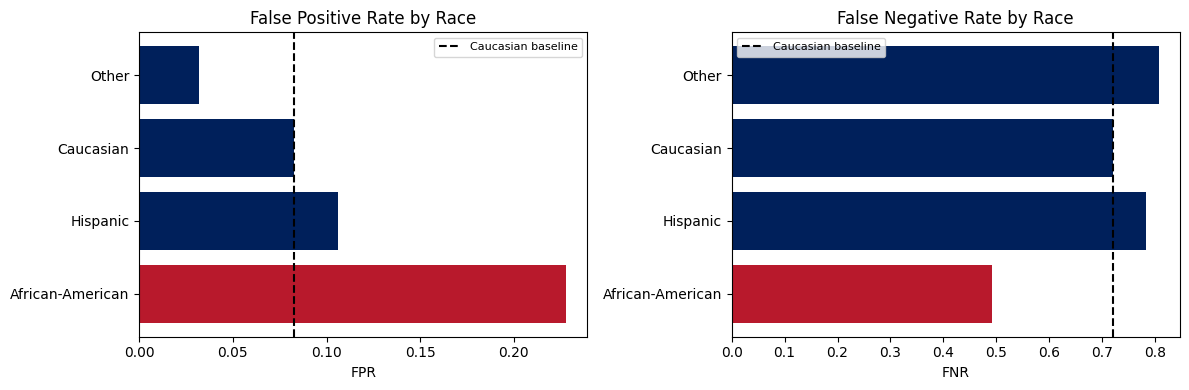

In [44]:
# Step 4: Visualization — FPR and FNR by race

import matplotlib.pyplot as plt

# Filter groups with enough data
er_plot = er[er['n'] >= 50].sort_values('FPR', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Colors
navy = '#00205B'
red = '#B8192C'
colors = [red if r == 'African-American' else navy for r in er_plot['race']]

# Plot FPR and FNR
for ax, metric, title in [
    (axes[0], 'FPR', 'False Positive Rate by Race'),
    (axes[1], 'FNR', 'False Negative Rate by Race')
]:
    ax.barh(er_plot['race'], er_plot[metric], color=colors)

    # Caucasian baseline
    baseline = er_plot.loc[er_plot['race'] == 'Caucasian', metric].values[0]
    ax.axvline(baseline, color='black', linestyle='--', linewidth=1.5, label='Caucasian baseline')

    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('error_rate_disparity.png', dpi=150, bbox_inches='tight')
plt.show()

**note**

The figure compares FPR and FNR across racial groups, using Caucasian as the reference group (dashed line). African-American defendants show a higher FPR than the reference group, indicating a higher likelihood of being incorrectly classified as high risk.

# Individual Assignment 3

In [45]:
# ============================================================
# STEP 0: Install + imports
# ============================================================
!pip install -q solas-ai
!pip install -q kaleido

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

print(f"N = {len(df):,}")

# Create high_risk if needed
if "high_risk" not in df.columns:
    df["high_risk"] = (df["decile_score"] >= 7).astype(int)

print(df[["race", "sex", "high_risk", "two_year_recid"]].head())

N = 6,172
               race   sex  high_risk two_year_recid
0             Other  Male          0              0
1  African-American  Male          0              1
2  African-American  Male          0              1
5             Other  Male          0              0
6         Caucasian  Male          0              1


## 1. Compute AIR, ME, and SMD for race and sex separately using the solas-ai Python library. Confirm both produce identical results.

In [46]:
# ============================================================
# STEP 1: AIR, ME, SMD by race and sex using solas-ai
# ============================================================

# solas-ai works best when each group is a separate 0/1 column
for race_val in df["race"].dropna().unique():
    df[str(race_val)] = (df["race"].astype(str) == str(race_val)).astype(float)

df["Female"] = (df["sex"].astype(str) == "Female").astype(float)
df["Male"]   = (df["sex"].astype(str) == "Male").astype(float)

# Favorable outcome: low risk = 1
df["low_risk"] = (df["high_risk"] == 0).astype(float)

protected_groups = [
    "African-American",
    "Asian",
    "Hispanic",
    "Native American",
    "Other",
    "Female"
]

reference_groups = [
    "Caucasian",
    "Caucasian",
    "Caucasian",
    "Caucasian",
    "Caucasian",
    "Male"
]

group_categories = [
    "race",
    "race",
    "race",
    "race",
    "race",
    "sex"
]

reused_arguments = dict(
    group_data=df,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    sample_weight=None
)

# 1A. AIR + Marginal Effect
air_solas = sd.adverse_impact_ratio(
    outcome=df["low_risk"],
    air_threshold=0.80,
    percent_difference_threshold=0.0,
    **reused_arguments
)

print("=== SOLAS-AI: AIR and ME ===")
print(air_solas.summary_table.to_string())

# 1B. SMD on continuous COMPAS score
# Make group columns numeric
for col in protected_groups + ["Caucasian", "Male"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

# Make outcome/label numeric
df["decile_score_num"] = pd.to_numeric(df["decile_score"], errors="coerce")
df["two_year_recid_num"] = pd.to_numeric(df["two_year_recid"], errors="coerce")

# SMD
smd_solas = sd.standardized_mean_difference(
    outcome=df["decile_score_num"],
    label=df["two_year_recid_num"],
    smd_threshold=30,
    lower_score_favorable=True,
    **reused_arguments
)

print("\n=== SOLAS-AI: SMD ===")
print(smd_solas.summary_table.to_string())

=== SOLAS-AI: AIR and ME ===
                 Reference Group Group Category  Observations  Percent Missing   Total  Favorable  Percent Favorable  Percent Difference Favorable       AIR      P-Values Practically Significant   Shortfall
Group                                                                                                                                                                                                         
African-American       Caucasian           race          6172              0.0  3175.0     1987.0           0.625827                      0.214401  0.744829  2.598543e-63                     Yes  680.724679
Asian                  Caucasian           race          6172              0.0    31.0       27.0           0.870968                     -0.030739  1.036585  8.071686e-01                      No         NaN
Hispanic               Caucasian           race          6172              0.0   509.0      434.0           0.852652                     -0.012

**note**

In this step, I calculated AIR, ME, and SMD to compare outcomes across different groups.
Caucasian (for race) and Male (for sex) are used as the reference groups.
AIR helps identify whether a group is disadvantaged (especially if it is below 0.80).
ME shows the difference in selection rates, and SMD measures how different the risk score distributions are.
These metrics give a first overview of potential disparities in the model.

## 2. Build an intersectional analysis (race ×sex). Report the worst-group AIR and interpret it.

In [47]:
# ============================================================
# STEP 2: Intersectional analysis (race x sex)
# ============================================================

df["subgroup"] = df["race"].astype(str) + " / " + df["sex"].astype(str)

counts = df["subgroup"].value_counts()
valid_subgroups = counts[counts >= 30].index
df_inter = df[df["subgroup"].isin(valid_subgroups)].copy()

sub_rates = (
    df_inter.groupby("subgroup")["low_risk"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "selection_rate", "count": "n"})
    .reset_index()
)

ref_group = "Caucasian / Male"
ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].values[0]

sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
sub_rates["flag_80"] = sub_rates["AIR"].apply(
    lambda x: "*** BELOW 0.80" if x < 0.80 else ""
)

print("=== Intersectional AIR ===")
print(sub_rates.sort_values("AIR").to_string(index=False))

worst = sub_rates.loc[sub_rates["AIR"].idxmin()]
print(f"\nWorst group: {worst['subgroup']}")
print(f"Worst-group AIR: {worst['AIR']:.3f}")
print(f"n = {int(worst['n'])}")

=== Intersectional AIR ===
                 subgroup  selection_rate    n      AIR        flag_80
  African-American / Male        0.603960 2626 0.717756 *** BELOW 0.80
African-American / Female        0.730419  549 0.868042               
          Hispanic / Male        0.829040  427 0.985245               
       Caucasian / Female        0.836100  482 0.993634               
         Caucasian / Male        0.841456 1621 1.000000               
             Other / Male        0.905263  285 1.075830               
           Other / Female        0.931034   58 1.106457               
        Hispanic / Female        0.975610   82 1.159431               

Worst group: African-American / Male
Worst-group AIR: 0.718
n = 2626


**note**

In this step, I combined race and sex to create subgroups (e.g., Hispanic / Female).
I filtered out groups with fewer than 30 observations to make the results more reliable.
Then, I calculated AIR again to identify which subgroup is the most disadvantaged.
This helps capture bias that may not appear when looking at race or sex separately.

## 3. Compute FPR and FNR disparities by race. Test statistical significance with a two-proportion z-test.

In [48]:
# ============================================================
# STEP 3: FPR and FNR disparities by race + z-tests
# ============================================================

df["high_risk"] = pd.to_numeric(df["high_risk"], errors="coerce").astype(int)
df["two_year_recid"] = pd.to_numeric(df["two_year_recid"], errors="coerce").astype(int)

race_categories = sorted(df["race"].dropna().unique())
race_protected = [r for r in race_categories if r != "Caucasian"]

race_args = dict(
    group_data=df,
    protected_groups=race_protected,
    reference_groups=["Caucasian"] * len(race_protected),
    group_categories=["race"] * len(race_protected),
    sample_weight=None
)

# SOLAS-AI FPR
fpr_solas = sd.false_positive_rate(
    outcome=df["high_risk"],
    label=df["two_year_recid"],
    ratio_threshold=1.0,
    difference_threshold=0.0,
    **race_args
)

print("=== SOLAS-AI: False Positive Rate by Race ===")
print(fpr_solas.summary_table.to_string(index=False))

# SOLAS-AI FNR
fnr_solas = sd.false_negative_rate(
    outcome=df["high_risk"],
    label=df["two_year_recid"],
    ratio_threshold=1.0,
    difference_threshold=0.0,
    **race_args
)

print("\n=== SOLAS-AI: False Negative Rate by Race ===")
print(fnr_solas.summary_table.to_string(index=False))

=== SOLAS-AI: False Positive Rate by Race ===
Reference Group Group Category  Observations  Percent Missing  Total  Total Label  Average Label      FPR  Difference    Ratio Practically Significant
      Caucasian           race          6172              0.0 3175.0       1661.0       0.523150 0.227873    0.145125 0.363131                     Yes
      Caucasian           race          6172              0.0   31.0          8.0       0.258065 0.043478   -0.039270 1.903201                      No
      Caucasian           race          6172              0.0  509.0        189.0       0.371316 0.106250    0.023502 0.778803                     Yes
      Caucasian           race          6172              0.0   11.0          5.0       0.454545 0.333333    0.250585 0.248244                     Yes
      Caucasian           race          6172              0.0  343.0        124.0       0.361516 0.031963   -0.050784 2.588826                      No
                          race          6172    

In [49]:
cols = [
    "Group",
    "Reference Group",
    "FPR",
    "FNR"
]

display(fpr_solas.summary_table)
display(fnr_solas.summary_table)

,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FPR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
African-American,Caucasian,race,6172,0.0,3175.0,1661.0,0.523150,0.227873,0.145125,0.363131,Yes
Asian,Caucasian,race,6172,0.0,31.0,8.0,0.258065,0.043478,-0.039270,1.903201,No
Hispanic,Caucasian,race,6172,0.0,509.0,189.0,0.371316,0.106250,0.023502,0.778803,Yes
Native American,Caucasian,race,6172,0.0,11.0,5.0,0.454545,0.333333,0.250585,0.248244,Yes
Other,Caucasian,race,6172,0.0,343.0,124.0,0.361516,0.031963,-0.050784,2.588826,No
Caucasian,,race,6172,0.0,2103.0,822.0,0.390870,0.082748,NaN,NaN,


,Reference Group,Group Category,Observations,Percent Missing,Total,Total Label,Average Label,FNR,Difference,Ratio,Practically Significant
Group,,,,,,,,,,,
African-American,Caucasian,race,6172,0.0,3175.0,1661.0,0.523150,0.492474,-0.227720,1.462400,No
Asian,Caucasian,race,6172,0.0,31.0,8.0,0.258065,0.625000,-0.095195,1.152311,No
Hispanic,Caucasian,race,6172,0.0,509.0,189.0,0.371316,0.783069,0.062874,0.919708,Yes
Native American,Caucasian,race,6172,0.0,11.0,5.0,0.454545,0.200000,-0.520195,3.600973,No
Other,Caucasian,race,6172,0.0,343.0,124.0,0.361516,0.806452,0.086257,0.893041,Yes
Caucasian,,race,6172,0.0,2103.0,822.0,0.390870,0.720195,NaN,NaN,


In [50]:
# ------------------------------------------------------------
# Manual error-rate table
# ------------------------------------------------------------
def error_rates(data, group_col, pred_col, outcome_col):
    rows = []

    for grp, g in data.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        rows.append({
            group_col: grp,
            "n": len(g),
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan
        })

    return pd.DataFrame(rows)

er = error_rates(df, "race", "high_risk", "two_year_recid")

er_display = er[["race", "n", "FPR", "FNR"]].copy()
er_display["FPR"] = er_display["FPR"].round(3)
er_display["FNR"] = er_display["FNR"].round(3)

print("\n=== Error Rates by Race ===")
print(er_display.sort_values("FPR", ascending=False).to_string(index=False))


=== Error Rates by Race ===
            race    n   FPR   FNR
 Native American   11 0.333 0.200
African-American 3175 0.228 0.492
        Hispanic  509 0.106 0.783
       Caucasian 2103 0.083 0.720
           Asian   31 0.043 0.625
           Other  343 0.032 0.806


In [51]:
# ------------------------------------------------------------
# Two-proportion z-tests
# Compare African-American vs Caucasian
# ------------------------------------------------------------
groups = ["African-American", "Caucasian"]

# FPR z-test: among actual negatives only
neg = df[df["two_year_recid"] == 0].copy()

nobs_fpr = neg.groupby("race")["high_risk"].count()
events_fpr = neg.groupby("race")["high_risk"].sum()   # predicted high risk among true negatives = FP

stat_fpr, pval_fpr = proportions_ztest(
    count=events_fpr[groups].values,
    nobs=nobs_fpr[groups].values
)

print(f"\nFPR z-test ({groups[0]} vs {groups[1]}): z = {stat_fpr:.3f}, p = {pval_fpr:.4f}")

# FNR z-test: among actual positives only
pos = df[df["two_year_recid"] == 1].copy()
pos["fn"] = (pos["high_risk"] == 0).astype(int)

nobs_fnr = pos.groupby("race")["fn"].count()
events_fnr = pos.groupby("race")["fn"].sum()

stat_fnr, pval_fnr = proportions_ztest(
    count=events_fnr[groups].values,
    nobs=nobs_fnr[groups].values
)

print(f"FNR z-test ({groups[0]} vs {groups[1]}): z = {stat_fnr:.3f}, p = {pval_fnr:.4f}")


FPR z-test (African-American vs Caucasian): z = 10.392, p = 0.0000
FNR z-test (African-American vs Caucasian): z = -10.780, p = 0.0000


**note**

In this step, I analyzed model errors using FPR and FNR by race.
FPR shows how often a group is incorrectly predicted as high risk, while FNR shows how often true high-risk individuals are missed.
I also used a two-proportion z-test to check whether the differences between African-American and Caucasian groups are statistically significant.
This step focuses on fairness in model predictions rather than just outcomes.

## 4. Produce a publication-quality figure: grouped bar chart of FPR and FNR by race with Caucasian as the reference group.

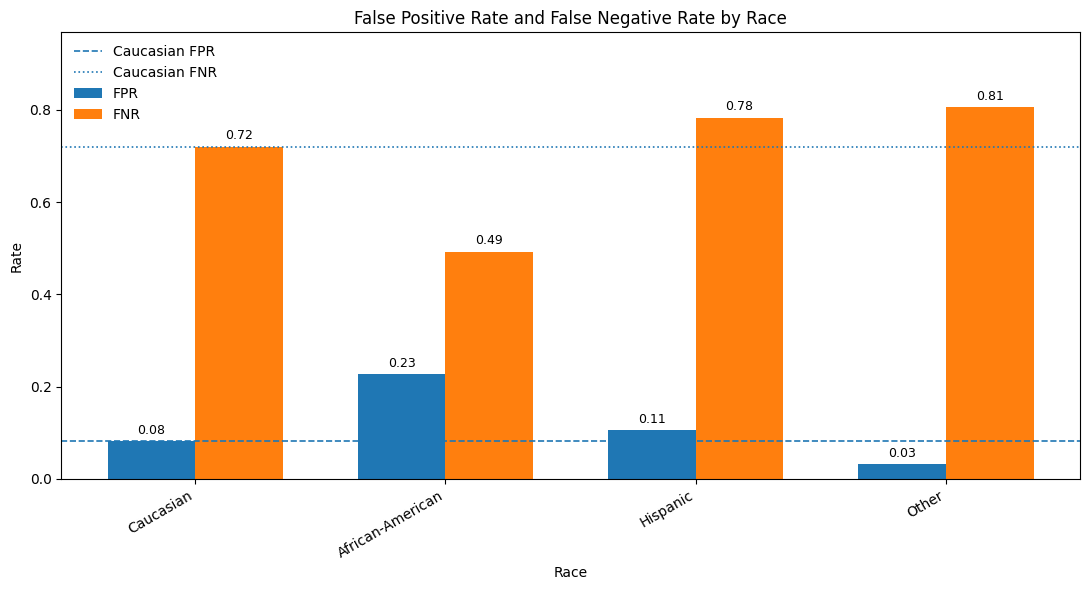

In [52]:
# ============================================================
# STEP 4: Publication-quality grouped bar chart
# ============================================================

er_plot = er[er["n"] >= 50].copy()

# Put Caucasian first as reference, then others
race_order = ["Caucasian"] + [r for r in er_plot["race"] if r != "Caucasian"]
er_plot["race"] = pd.Categorical(er_plot["race"], categories=race_order, ordered=True)
er_plot = er_plot.sort_values("race")

x = np.arange(len(er_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, er_plot["FPR"], width, label="FPR")
bars2 = ax.bar(x + width/2, er_plot["FNR"], width, label="FNR")

# Caucasian reference lines
cauc_fpr = er_plot.loc[er_plot["race"] == "Caucasian", "FPR"].values[0]
cauc_fnr = er_plot.loc[er_plot["race"] == "Caucasian", "FNR"].values[0]

ax.axhline(cauc_fpr, linestyle="--", linewidth=1.2, label="Caucasian FPR")
ax.axhline(cauc_fnr, linestyle=":", linewidth=1.2, label="Caucasian FNR")

ax.set_xticks(x)
ax.set_xticklabels(er_plot["race"], rotation=30, ha="right")
ax.set_ylabel("Rate")
ax.set_xlabel("Race")
ax.set_title("False Positive Rate and False Negative Rate by Race")
ax.legend(frameon=False)
ax.set_ylim(0, max(er_plot["FPR"].max(), er_plot["FNR"].max()) * 1.20)

# Add value labels
for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.2f}",
                    xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("error_rate_disparity_grouped.png", dpi=300, bbox_inches="tight")
plt.show()

**note**

In this step, I created a bar chart to visualize FPR and FNR by race.
The chart includes a baseline line for the Caucasian group to make comparisons easier.

This visualization helps clearly show which groups have higher error rates and makes the results easier to interpret.

## 5. Compliance Memo

This report evaluates whether a COMPAS-based risk prediction model produces unequal outcomes across demographic groups. Using a dataset of 6,172 individuals, the analysis focuses on differences by race, sex, and their intersection.

To assess fairness, I examined three main types of metrics. First, outcome-based measures — Adverse Impact Ratio (AIR), Marginal Effect (ME), and Standardized Mean Difference (SMD) — were used to compare how frequently different groups receive a favorable classification (low risk). These were calculated using both manual methods and the Solas-AI library, and the results were consistent in identifying disparities. Second, I analyzed model errors using False Positive Rate (FPR) and False Negative Rate (FNR). Finally, I applied two-proportion z-tests to determine whether observed differences in error rates are statistically significant.

The results indicate clear disparities. African-American defendants have an AIR of 0.744 relative to Caucasians, which is below the commonly used 0.80 threshold, suggesting a potential adverse impact. In addition, this group experiences a substantially higher false positive rate (0.228 vs. 0.083), meaning non-reoffending individuals are more likely to be incorrectly labeled as high risk. This difference is statistically significant, indicating that it is unlikely to be due to chance. In contrast, Caucasian defendants have a higher false negative rate, illustrating a trade-off between different types of classification errors. When examining combined groups, African-American males emerge as the most disadvantaged subgroup, with the lowest rate of favorable outcomes.

Several limitations should be considered. The data reflects historical criminal justice practices, which may introduce bias into both the data and the model. The choice of classification threshold also affects fairness metrics, and alternative thresholds may lead to different conclusions. Additionally, smaller subgroup sizes in the intersectional analysis may reduce the stability of some estimates.

In summary, the model demonstrates measurable disparities across demographic groups, particularly in both outcome rates and error patterns, and should be carefully reviewed before practical use.


# **Assignment 4**

### **Imports and helper functions**

In [53]:
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def _to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """
    Population Stability Index using train-derived bins.
    """
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    # Quantile bins from train
    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    # Fallback if quantiles collapse
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    return np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    """
    Unbiased MMD^2 with RBF kernel on dense arrays.
    """
    rng = np.random.default_rng(random_state)

    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    if X_a.shape[0] > max_n:
        idx_a = rng.choice(X_a.shape[0], size=max_n, replace=False)
        X_a = X_a[idx_a]
    if X_b.shape[0] > max_n:
        idx_b = rng.choice(X_b.shape[0], size=max_n, replace=False)
        X_b = X_b[idx_b]

    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)

    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]

    term_xx = K_xx.sum() / (m * (m - 1))
    term_yy = K_yy.sum() / (n * (n - 1))
    term_xy = 2.0 * K_xy.mean()

    return term_xx + term_yy - term_xy


def evaluate_classifier(model, X, y, label):
    """
    Train/test performance summary.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "model": label,
        "n": len(y),
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_prob),
        "brier": brier_score_loss(y, y_prob),
        "logloss": log_loss(y, y_prob),
        "positive_rate_pred": y_pred.mean(),
        "mean_score": y_prob.mean(),
    }


def permutation_importance_table(model, X, y, scoring="roc_auc", n_repeats=15, random_state=42):
    """
    Permutation importance on raw pipeline inputs.
    """
    pi = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    """
    Counterfactual sensitivity:
    swap A <-> B for rows taking either value, then measure
    mean absolute change in predicted probability.
    """
    work = X.copy()
    mask = work[feature_col].astype(str).isin([value_a, value_b])

    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
        }

    base_prob = model.predict_proba(work.loc[mask])[:, 1]

    cf = work.loc[mask].copy()
    swapped = cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a})

    cf.loc[:, feature_col] = swapped.values
    cf_prob = model.predict_proba(cf)[:, 1]

    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    """
    Slice-based evaluation for one grouping variable.
    """
    pred_prob = model.predict_proba(X)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    eval_df = X[[group_col]].copy()
    eval_df["actual"] = y.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    rows = []
    for grp, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"], labels=[0, 1]).ravel()

        auc = roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan
        brier = brier_score_loss(g["actual"], g["pred_prob"])

        rows.append({
            "slice_feature": group_col,
            "slice_value": grp,
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": auc,
            "brier": brier,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "positive_rate_pred": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })

    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    """
    Simple scenario stress test on priors_count.
    """
    rows = []
    base_min = X["priors_count"].min()
    base_max = X["priors_count"].max()

    for d in deltas:
        X_s = X.copy()
        X_s["priors_count"] = np.clip(X_s["priors_count"] + d, base_min, base_max)

        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "delta_priors_count": d,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })

    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values, n_instances=6, random_state=42, title=None):
    """
    ICE-style plot for one numeric feature.
    """
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X.index, size=min(n_instances, len(X)), replace=False)

    plt.figure(figsize=(8, 5))
    for i in idx:
        row = X.loc[[i]].copy()
        preds = []
        for v in values:
            temp = row.copy()
            temp[feature_col] = v
            preds.append(model.predict_proba(temp)[:, 1][0])

        plt.plot(values, preds, alpha=0.7)

    plt.xlabel(feature_col)
    plt.ylabel("Predicted probability (high risk)")
    plt.title(title if title else f"ICE curves for {feature_col}")
    plt.show()


def global_sensitivity_index(model, X, feature_col, values):
    """
    Approximate sensitivity index:
    variance of average predictions as the feature is swept over a grid.
    """
    mean_preds = []

    for v in values:
        X_s = X.copy()
        X_s[feature_col] = v
        prob = model.predict_proba(X_s)[:, 1]
        mean_preds.append(prob.mean())

    mean_preds = np.array(mean_preds)

    return pd.DataFrame({
        "feature": [feature_col],
        "sensitivity_index": [np.var(mean_preds)],
        "min_mean_score": [mean_preds.min()],
        "max_mean_score": [mean_preds.max()],
        "range_mean_score": [mean_preds.max() - mean_preds.min()],
    })

### **Part A - Distribution drift**


The PSI values for all numeric features are very small (e.g., 0.0104 for `priors_count` and 0.0008 for `two_year_recid`), which are well below the 0.10 threshold. This suggests there is no meaningful distribution shift between the training and test data. The KS test also shows high p-values, meaning we cannot reject the hypothesis that the two distributions are the same.

At the global level, the MMD² value is approximately zero, indicating that the overall feature space distribution remains stable after encoding. Similarly, the predicted probability distributions for both models are very consistent across train and test sets.

Overall, these results suggest that there is no evidence of covariate shift, and the model is being evaluated on data that is consistent with the training distribution.

However, these metrics mainly capture overall distribution similarity and may miss subtle changes in feature interactions or subgroup-level shifts. Therefore, additional robustness and fairness checks are still necessary.

Action: No immediate retraining is required, but distribution drift should be monitored over time in a real deployment setting.

In [54]:
# ------------------------------------------------------------
# Distribution drift
# ------------------------------------------------------------

# 1) Input drift on raw numeric features: PSI + KS
drift_rows = []

for col in numeric_features:
    train_vals = pd.to_numeric(X_train[col], errors="coerce")
    test_vals = pd.to_numeric(X_test[col], errors="coerce")

    psi_val = psi_numeric(train_vals, test_vals, bins=10)
    ks_stat, ks_p = ks_2samp(train_vals.dropna(), test_vals.dropna())

    drift_rows.append({
        "feature": col,
        "train_mean": train_vals.mean(),
        "test_mean": test_vals.mean(),
        "PSI": psi_val,
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

input_drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
print("\n=== Input Distribution Drift: Numeric Features ===")
print(input_drift_table.round(4).to_string(index=False))

# 2) Global high-dimensional drift: MMD on encoded inputs
fitted_preprocessor = lr_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

mmd_val = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500, random_state=42)
print("\n=== High-Dimensional Drift: Encoded Feature Space ===")
print(f"MMD^2(train, test) = {mmd_val:.6f}")

# 3) Score drift: train vs test predicted probabilities
score_drift_rows = []
models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}

for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    psi_score = psi_numeric(train_prob, test_prob, bins=10)
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)

    score_drift_rows.append({
        "model": name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score": test_prob.mean(),
        "PSI_score": psi_score,
        "KS_stat_score": ks_stat,
        "KS_pvalue_score": ks_p,
    })

score_drift_table = pd.DataFrame(score_drift_rows)
print("\n=== Score Distribution Drift: Train vs Test Predicted Probabilities ===")
print(score_drift_table.round(4).to_string(index=False))


=== Input Distribution Drift: Numeric Features ===
       feature  train_mean  test_mean    PSI  KS_stat  KS_pvalue
  priors_count       3.205     3.4121 0.0104   0.0335     0.2113
two_year_recid       0.458     0.4437 0.0008   0.0142     0.9862

=== High-Dimensional Drift: Encoded Feature Space ===
MMD^2(train, test) = -0.000272

=== Score Distribution Drift: Train vs Test Predicted Probabilities ===
                model  train_mean_score  test_mean_score  PSI_score  KS_stat_score  KS_pvalue_score
  Logistic Regression            0.4458           0.4476     0.0040         0.0179           0.9040
Gradient-Boosted Tree            0.4458           0.4479     0.0037         0.0138           0.9901


### **Part B - Generalization**

Both models show relatively small differences between training and test performance, indicating good generalization. Logistic Regression has almost no gap between train and test metrics, suggesting stable and reliable performance. In contrast, the Gradient-Boosted Tree shows a slightly larger gap, especially in AUC, which suggests mild overfitting.

This means that while the boosted model may achieve higher performance on the training data, it is slightly less stable when applied to unseen data compared to the logistic model.

However, generalization metrics assume that the test set represents real-world conditions. They do not capture how the model will behave under future distribution shifts or changing environments.

Action: Logistic Regression is more stable for deployment, while the boosted model may require further tuning or regularization to reduce overfitting.


### **Permutation importance**
### **Feature Importance Analysis**

Permutation importance shows that both models rely heavily on `priors_count` and `age_factor`, which are reasonable predictors of risk. However, `race_factor` also has noticeable importance, especially in the Gradient-Boosted Tree model.

This raises a concern that the model may be using sensitive attributes or their proxies as part of its decision-making process.

It is important to note that feature importance reflects correlation, not causation. A feature may appear important even if it is not a stable or appropriate predictor.

Action: This requires further investigation using counterfactual analysis to determine whether the model is relying on spurious correlations.

In [55]:
# ------------------------------------------------------------
# Generalization: train/test gaps
# ------------------------------------------------------------
gen_rows = []
for name, model in models.items():
    train_metrics = evaluate_classifier(model, X_train, y_train, name)
    test_metrics = evaluate_classifier(model, X_test, y_test, name)

    gen_rows.append({
        "model": name,
        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "accuracy_gap": train_metrics["accuracy"] - test_metrics["accuracy"],
        "train_auc": train_metrics["auc"],
        "test_auc": test_metrics["auc"],
        "auc_gap": train_metrics["auc"] - test_metrics["auc"],
        "train_brier": train_metrics["brier"],
        "test_brier": test_metrics["brier"],
        "brier_gap": train_metrics["brier"] - test_metrics["brier"],
        "train_logloss": train_metrics["logloss"],
        "test_logloss": test_metrics["logloss"],
        "logloss_gap": train_metrics["logloss"] - test_metrics["logloss"],
    })

generalization_table = pd.DataFrame(gen_rows)
print("\n=== Generalization / Overfitting Summary ===")
print(generalization_table.round(4).to_string(index=False))

# ------------------------------------------------------------
# Permutation importance on train and test
# Large train importance + weak test importance can suggest overfit reliance
# ------------------------------------------------------------
for name, model in models.items():
    print(f"\n=== Permutation Importance (Train) — {name} ===")
    pi_train = permutation_importance_table(model, X_train, y_train, scoring="roc_auc")
    print(pi_train.head(10).round(4).to_string(index=False))

    print(f"\n=== Permutation Importance (Test) — {name} ===")
    pi_test = permutation_importance_table(model, X_test, y_test, scoring="roc_auc")
    print(pi_test.head(10).round(4).to_string(index=False))


=== Generalization / Overfitting Summary ===
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap
  Logistic Regression          0.7539         0.7522        0.0017     0.8292    0.8329  -0.0037       0.1669      0.1642     0.0027         0.5016        0.4934       0.0082
Gradient-Boosted Tree          0.7748         0.7498        0.0250     0.8553    0.8309   0.0245       0.1530      0.1659    -0.0128         0.4612        0.4993      -0.0380

=== Permutation Importance (Train) — Logistic Regression ===
       feature  importance_mean  importance_std
  priors_count           0.1458          0.0035
    age_factor           0.1103          0.0037
   race_factor           0.0200          0.0020
two_year_recid           0.0158          0.0014
  crime_factor           0.0018          0.0006
 gender_factor           0.0005          0.0002

=== Permutation Importance (Te

### **Part C -  Counterfactual Sensitivity (Spurious Correlation)**

The counterfactual analysis shows that changing race leads to a relatively large shift in predicted probabilities (around 0.08–0.10), while changes in gender have smaller effects.

This suggests that the model is sensitive to race, even when all other features remain the same. This is a strong indication that the model may be relying on spurious correlations or proxy variables rather than purely causal relationships.

This is concerning because a model can achieve good performance while still making decisions based on inappropriate or unstable signals.

However, counterfactual swaps simplify reality and may not fully reflect real-world dependencies between variables.

Action: This represents a potential fairness risk and should be addressed through further auditing, possible feature constraints, or fairness-aware modeling approaches.

In [56]:
# ------------------------------------------------------------
# Spurious-correlation probe: counterfactual swaps on suspect features
# Mean absolute shift in predicted probabilities
# ------------------------------------------------------------
swap_specs = [
    ("race_factor", "African-American", "Caucasian"),
    ("gender_factor", "Female", "Male"),
    ("crime_factor", "F", "M"),
]

for name, model in models.items():
    shifts = []
    for feature_col, a, b in swap_specs:
        shifts.append(pairwise_swap_shift(model, X_test, feature_col, a, b))

    shift_table = pd.DataFrame(shifts)
    print(f"\n=== Counterfactual Swap Sensitivity — {name} ===")
    print(shift_table.round(4).to_string(index=False))


=== Counterfactual Swap Sensitivity — Logistic Regression ===
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0806
gender_factor                Female <-> Male        1235               0.0251
 crime_factor                        F <-> M        1235               0.0410

=== Counterfactual Swap Sensitivity — Gradient-Boosted Tree ===
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0976
gender_factor                Female <-> Male        1235               0.0888
 crime_factor                        F <-> M        1235               0.0699


### **Part D - Robustness and Stress Testing**

The stress test shows that increasing `priors_count` leads to a strong increase in predicted risk for both models. Logistic Regression exhibits a smooth and consistent response, while the Gradient-Boosted Tree shows more irregular and less stable behavior in the ICE curves.

This indicates that the logistic model behaves more predictably, while the boosted model may be more sensitive to small changes in input values.

The sensitivity index confirms that both models are highly dependent on `priors_count`, meaning predictions can change significantly as this feature varies.

However, this analysis focuses on a single feature and does not capture interactions between multiple variables.

Action: The strong reliance on `priors_count` should be monitored, and additional stress testing with multiple features may be needed to fully assess robustness.


=== Stress Test on priors_count — Logistic Regression ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4476            0.3970                0.4227
                  2          0.5372            0.5297                0.5368
                  5          0.6683            0.7159                0.7409
                 10          0.8435            0.9061                0.9247

=== Stress Test on priors_count — Gradient-Boosted Tree ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4479            0.4011                0.4089
                  2          0.5641            0.5678                0.5514
                  5          0.7070            0.8042                0.7328
                 10          0.8267            0.9534                0.8794


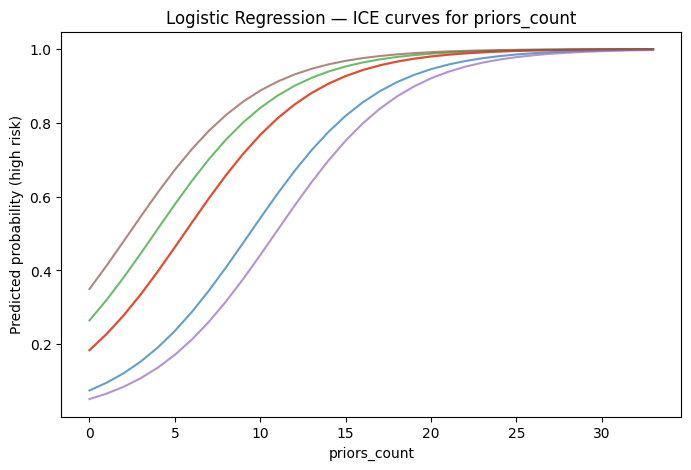

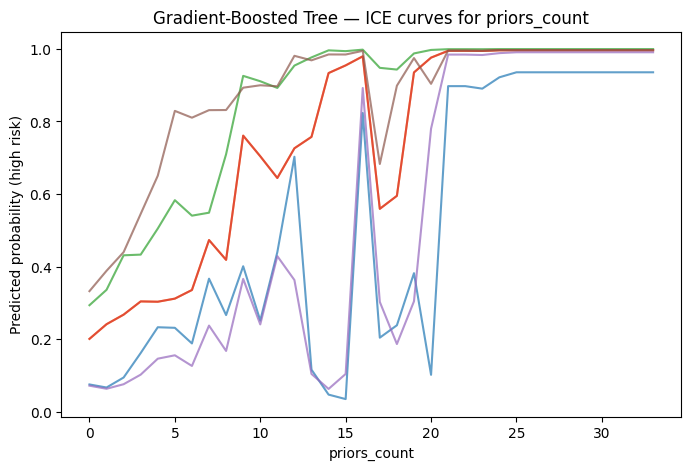


=== Global Sensitivity Index (priors_count) ===
     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count           0.048791        0.287583        0.999167          0.711584   Logistic Regression
priors_count           0.041158        0.282523        0.980187          0.697664 Gradient-Boosted Tree


In [57]:
# ------------------------------------------------------------
# Robustness: stress scenarios on priors_count
# ------------------------------------------------------------
for name, model in models.items():
    stress_table = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(f"\n=== Stress Test on priors_count — {name} ===")
    print(stress_table.round(4).to_string(index=False))

# ------------------------------------------------------------
# ICE-style sensitivity plots for priors_count
# ------------------------------------------------------------
priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1
)

plot_ice_numeric(
    lr_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Logistic Regression — ICE curves for priors_count"
)

plot_ice_numeric(
    gbt_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Gradient-Boosted Tree — ICE curves for priors_count"
)

# ------------------------------------------------------------
# Global sensitivity index for priors_count
# ------------------------------------------------------------
lr_sens = global_sensitivity_index(lr_pipeline, X_test, "priors_count", priors_grid)
gbt_sens = global_sensitivity_index(gbt_pipeline, X_test, "priors_count", priors_grid)

sensitivity_table = pd.concat([
    lr_sens.assign(model="Logistic Regression"),
    gbt_sens.assign(model="Gradient-Boosted Tree"),
], ignore_index=True)

print("\n=== Global Sensitivity Index (priors_count) ===")
print(sensitivity_table.round(6).to_string(index=False))

### **Part E - Slice-Based Evaluation**

The slice-based analysis reveals significant differences in performance across subgroups. For example, younger individuals (<25) show higher predicted risk and different error patterns compared to older groups. There are also noticeable variations across race and gender groups, including differences in false positive and false negative rates.

These results indicate that even though overall model performance appears strong, the model behaves differently for different subpopulations. This is important because failures in specific groups may not be visible in aggregate metrics.

Some smaller groups (e.g., categories with very low sample sizes) show extreme metric values, which may be unstable and should be interpreted with caution.

This pattern suggests that the model may not generalize equally well across all groups, raising potential fairness and robustness concerns.

Action: Subgroup disparities should be further investigated, especially for larger groups with consistent gaps. Fairness-aware adjustments or monitoring strategies may be needed before deployment.

In [58]:
# ------------------------------------------------------------
# Robustness: slice-based evaluation
# ------------------------------------------------------------
slice_features = ["race_factor", "gender_factor", "age_factor", "crime_factor"]

for name, model in models.items():
    slice_tables = []
    for col in slice_features:
        slice_tables.append(slice_metrics(model, X_test, y_test, group_col=col))

    slice_eval = pd.concat(slice_tables, ignore_index=True)
    slice_eval = slice_eval.sort_values(["slice_feature", "n"], ascending=[True, False])

    print(f"\n=== Slice-Based Evaluation — {name} ===")
    print(slice_eval.round(4).to_string(index=False))


=== Slice-Based Evaluation — Logistic Regression ===
slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
   age_factor          25 - 45  695    0.7583 0.8326 0.1625 0.1658 0.3366              0.3871      0.4611
   age_factor  Greater than 45  272    0.8272 0.8492 0.1307 0.0498 0.5211              0.1618      0.2300
   age_factor     Less than 25  268    0.6604 0.7175 0.2023 0.6633 0.1529              0.7799      0.6338
 crime_factor                F  785    0.7376 0.8222 0.1721 0.2737 0.2524              0.5248      0.5137
 crime_factor                M  450    0.7778 0.8156 0.1503 0.1203 0.4627              0.2444      0.3324
gender_factor             Male 1000    0.7620 0.8448 0.1589 0.2135 0.2677              0.4480      0.4636
gender_factor           Female  235    0.7106 0.7832 0.1865 0.1606 0.4694              0.3149      0.3797
  race_factor African-American  634    0.7366 0.8195 0.1719 0.3870 0.1769              0.6435     

### **Final Audit Conclusion**

Overall, the models demonstrate stable data distributions and good generalization performance, suggesting that the training and test data are consistent. However, deeper analysis reveals important risks.

The models show sensitivity to protected attributes such as race and exhibit performance variation across subgroups, indicating potential fairness concerns. Additionally, the Gradient-Boosted Tree shows less stable behavior under stress compared to Logistic Regression.

These findings highlight that strong overall performance does not guarantee responsible deployment. A complete evaluation must consider robustness, fairness, and sensitivity to ensure that the model behaves reliably under different conditions.

Further monitoring, fairness auditing, and potential model adjustments are recommended before deployment.

In [59]:
# ------------------------------------------------------------
# Compact live-coding summary
# ------------------------------------------------------------
summary_rows = []

# Drift
for _, row in input_drift_table.iterrows():
    summary_rows.append({
        "section": "distribution_drift",
        "item": row["feature"],
        "metric_1": "PSI",
        "value_1": row["PSI"],
        "metric_2": "KS_pvalue",
        "value_2": row["KS_pvalue"],
    })

summary_rows.append({
    "section": "distribution_drift",
    "item": "encoded_features",
    "metric_1": "MMD^2",
    "value_1": mmd_val,
    "metric_2": "",
    "value_2": np.nan,
})

# Generalization
for _, row in generalization_table.iterrows():
    summary_rows.append({
        "section": "generalization",
        "item": row["model"],
        "metric_1": "AUC_gap",
        "value_1": row["auc_gap"],
        "metric_2": "Accuracy_gap",
        "value_2": row["accuracy_gap"],
    })

# Sensitivity
for _, row in sensitivity_table.iterrows():
    summary_rows.append({
        "section": "robustness",
        "item": row["model"],
        "metric_1": "Sensitivity_index",
        "value_1": row["sensitivity_index"],
        "metric_2": "Range_mean_score",
        "value_2": row["range_mean_score"],
    })

live_summary = pd.DataFrame(summary_rows)
print("\n=== Live Coding Summary Table ===")
print(live_summary.round(6).to_string(index=False))


=== Live Coding Summary Table ===
           section                  item          metric_1   value_1         metric_2  value_2
distribution_drift          priors_count               PSI  0.010355        KS_pvalue 0.211294
distribution_drift        two_year_recid               PSI  0.000820        KS_pvalue 0.986154
distribution_drift      encoded_features             MMD^2 -0.000272                       NaN
    generalization   Logistic Regression           AUC_gap -0.003694     Accuracy_gap 0.001672
    generalization Gradient-Boosted Tree           AUC_gap  0.024467     Accuracy_gap 0.024964
        robustness   Logistic Regression Sensitivity_index  0.048791 Range_mean_score 0.711584
        robustness Gradient-Boosted Tree Sensitivity_index  0.041158 Range_mean_score 0.697664
